# Modelo convolucional 1D v2 (U-Net residual)

Versión mejorada del modelo convolucional 1D. Mantiene el planteamiento de superresolución del modelo base (entrada interpolada sobre la malla de SDSS y conexión residual global) e incorpora tres mejoras:

1. **Pérdida ponderada por la varianza inversa de SDSS** (`y_ivar`): los píxeles ruidosos del espectro objetivo pesan menos y los píxeles inválidos (`ivar = 0`) se enmascaran, de modo que la red aprende el espectro subyacente y no la realización concreta del ruido.
2. **Canal de entrada adicional con el error de flujo de Gaia** (`X_err`): la red sabe qué zonas de su entrada son fiables.
3. **Mejora de datos con ruido realista**: en cada época se perturba el flujo de Gaia con ruido gaussiano de amplitud igual a su error observacional, lo que multiplica de forma efectiva el conjunto de entrenamiento.

La arquitectura pasa de una pila de bloques residuales a una **U-Net 1D** con bloques residuales y atención de canal (*squeeze-and-excitation*). Con tres niveles de submuestreo, el campo receptivo cubre todo el espectro, por lo que la red puede corregir tanto el detalle de las líneas como el desajuste de continuo a gran escala entre Gaia y SDSS.


In [1]:
import sys

import numpy as np
from pathlib import Path

# Localizamos la carpeta 'solution' subiendo desde el directorio de trabajo, sin
# suponer dónde arranca el kernel: sirve tanto la carpeta de este cuaderno como
# 'models' o la raíz del repositorio. Su marca es el fichero 'pyproject.toml'.
SOLUTION_DIR = next(
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "solution")
    if (candidate / "pyproject.toml").is_file()
)

DATA_DIR = SOLUTION_DIR / "data"
MODELS_DIR = SOLUTION_DIR / "models"
CNN_DIR = MODELS_DIR / "cnn"
ISPEC_DIR = SOLUTION_DIR / "lib" / "iSpec"

# 'services' está en la carpeta de este cuaderno, 'iSpec_functions' en 'models' e
# iSpec no se instala como dependencia: los tres se importan desde su carpeta
sys.path[:0] = [str(CNN_DIR), str(MODELS_DIR), str(ISPEC_DIR)]

# Ficheros de checkpoint. Esta celda no carga datos, de modo que la recarga de
# una sesión anterior solo necesita ejecutar esta celda y la de recarga.
MODEL_PATH = CNN_DIR / "cnn-v2.keras"
HISTORY_PATH = CNN_DIR / "cnn-v2_training_history.csv"
SUMMARY_PATH = CNN_DIR / "cnn-v2_training_summary.json"
TEST_DATA_PATH = CNN_DIR / "cnn-v2_test_data.npz"

print("Carpeta de trabajo:", SOLUTION_DIR)

Carpeta de trabajo: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution


In [2]:
# El nombre del fichero puede llevar la fecha de generación como prefijo
data_dir = DATA_DIR / "splits"
candidates = (
    sorted(data_dir.glob("*processed_data_no_duplicates.npz"))
    + sorted(data_dir.glob("*processed_data.npz"))
)
processed_path = candidates[0]
print("Usando:", processed_path)

data = np.load(processed_path)
print(data.files)

Usando: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/data/splits/2026-08-16_processed_data_no_duplicates.npz
['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'y_ivar_train', 'y_ivar_val', 'y_ivar_test', 'gaia_wavelength', 'sdss_wavelength']


In [3]:
# Datos de entrada Gaia: flujo y error de flujo
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

X_err_train = data["X_err_train"]
X_err_val = data["X_err_val"]
X_err_test = data["X_err_test"]

# Datos objetivo SDSS: flujo y varianza inversa
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

y_ivar_train = data["y_ivar_train"]
y_ivar_val = data["y_ivar_val"]
y_ivar_test = data["y_ivar_test"]

# IDs de Gaia y SDSS
X_id_test = data["X_id_test"]
y_id_test = data["y_id_test"]

# Longitudes de onda
gaia_wavelength = data["gaia_wavelength"]
sdss_wavelength = data["sdss_wavelength"]

print("Gaia:", X_train.shape, "| SDSS:", y_train.shape)

Gaia: (32656, 201) | SDSS: (32656, 2666)


Normalizamos cada par de espectros con la mediana del flujo de Gaia, igual que en el modelo base. El error de Gaia se normaliza con la misma escala para que siga siendo coherente con su flujo.

Los pesos por píxel se derivan de la varianza inversa de SDSS: al dividir el flujo por la escala `s`, la varianza queda dividida por `s²`, luego la varianza inversa del flujo normalizado es `ivar · s²`. Dentro de cada espectro normalizamos los pesos para que su media sobre los píxeles válidos sea 1: así todos los objetos contribuyen por igual a la pérdida y los pesos solo redistribuyen la importancia entre píxeles. Un recorte superior evita que unos pocos píxeles de varianza muy baja dominen el entrenamiento; los píxeles con `ivar = 0` quedan enmascarados con peso 0.


In [4]:
# Escala por espectro: mediana del flujo de Gaia
X_scale_train = np.nanmedian(np.abs(X_train), axis=1, keepdims=True)
X_scale_val = np.nanmedian(np.abs(X_val), axis=1, keepdims=True)
X_scale_test = np.nanmedian(np.abs(X_test), axis=1, keepdims=True)

X_train_norm = X_train / X_scale_train
X_val_norm = X_val / X_scale_val
X_test_norm = X_test / X_scale_test

X_err_train_norm = X_err_train / X_scale_train
X_err_val_norm = X_err_val / X_scale_val
X_err_test_norm = X_err_test / X_scale_test

# El objetivo se normaliza con la misma escala que su entrada
y_train_norm = y_train / X_scale_train
y_val_norm = y_val / X_scale_val
y_test_norm = y_test / X_scale_test


def build_pixel_weights(y_ivar, scale, max_weight=10.0):
    # Varianza inversa del flujo normalizado
    weights = y_ivar * scale**2
    # Media 1 sobre los píxeles válidos de cada espectro
    valid = np.where(weights > 0, weights, np.nan)
    weights = weights / np.nanmean(valid, axis=1, keepdims=True)
    return np.clip(weights, 0.0, max_weight).astype(np.float32)


w_train = build_pixel_weights(y_ivar_train, X_scale_train)
w_val = build_pixel_weights(y_ivar_val, X_scale_val)
w_test = build_pixel_weights(y_ivar_test, X_scale_test)

print("Fracción de píxeles enmascarados (ivar = 0):", (w_train == 0).mean())

Fracción de píxeles enmascarados (ivar = 0): 0.003406822277592916


La interpolación lineal de Gaia sobre la malla de SDSS es una operación lineal fija, por lo que puede expresarse como una matriz de `(n_sdss, n_gaia)`. Esto permite aplicarla dentro del flujo de datos de TensorFlow, de modo que el ruido de la mejora de datos se añade sobre el espectro nativo de Gaia (donde es estadísticamente correcto) y la interpolación se hace después, en cada época.


In [5]:
from services.persistence import save_test_data


def build_interp_matrix(source_wavelength, target_wavelength):
    idx = np.searchsorted(source_wavelength, target_wavelength)
    idx = np.clip(idx, 1, len(source_wavelength) - 1)
    left = idx - 1
    right = idx
    t = (target_wavelength - source_wavelength[left]) / (
        source_wavelength[right] - source_wavelength[left]
    )
    # Fuera del rango de Gaia se mantiene el valor extremo, igual que np.interp
    t = np.clip(t, 0.0, 1.0)
    matrix = np.zeros(
        (len(target_wavelength), len(source_wavelength)), dtype=np.float32
    )
    rows = np.arange(len(target_wavelength))
    matrix[rows, left] = 1.0 - t
    matrix[rows, right] = t
    return matrix


interp_matrix = build_interp_matrix(gaia_wavelength, sdss_wavelength)

# Comprobación: la matriz reproduce np.interp
reference = np.interp(sdss_wavelength, gaia_wavelength, X_train_norm[0])
assert np.allclose(X_train_norm[0] @ interp_matrix.T, reference, atol=1e-5)


def interpolate_pair(flux_norm, err_norm):
    flux_interp = (flux_norm @ interp_matrix.T).astype(np.float32)
    err_interp = (err_norm @ interp_matrix.T).astype(np.float32)
    return flux_interp, err_interp


X_val_flux_interp, X_val_err_interp = interpolate_pair(X_val_norm, X_err_val_norm)
X_test_flux_interp, X_test_err_interp = interpolate_pair(X_test_norm, X_err_test_norm)

print(X_val_flux_interp.shape, "->", y_val_norm.shape)

# Guardamos las variables del conjunto de test que consumen las celdas
# posteriores al entrenamiento, para poder ejecutarlas sin repetir estas celdas
save_test_data(
    TEST_DATA_PATH,
    X_test=X_test,
    y_test=y_test,
    X_id_test=X_id_test,
    y_id_test=y_id_test,
    gaia_wavelength=gaia_wavelength,
    sdss_wavelength=sdss_wavelength,
    X_scale_test=X_scale_test,
    X_test_flux_interp=X_test_flux_interp,
    X_test_err_interp=X_test_err_interp
)

2026-08-28 00:22:58.659873: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-28 00:22:58.748838: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-28 00:23:01.634149: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


(4082, 2666) -> (4082, 2666)


PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/cnn/cnn-v2_test_data.npz')

Flujos de datos de entrenamiento y evaluación. El de entrenamiento añade en cada época ruido gaussiano al flujo de Gaia con la amplitud de su error observacional y después interpola; los de validación y test solo interpolan. Cada elemento produce las dos entradas del modelo (flujo interpolado y error interpolado), el objetivo y los pesos por píxel.


In [6]:
import tensorflow as tf

batch_size = 64
interp_matrix_tf = tf.constant(interp_matrix)


def project_to_sdss(flux, err, target, weight):
    flux_interp = tf.linalg.matvec(interp_matrix_tf, flux)
    err_interp = tf.linalg.matvec(interp_matrix_tf, err)
    inputs = (flux_interp[:, None], err_interp[:, None])
    return inputs, target[:, None], weight


def augment_with_noise(flux, err, target, weight):
    noise = tf.random.normal(tf.shape(flux)) * err
    return flux + noise, err, target, weight


def as_tensor_slices(flux, err, target, weight):
    return tf.data.Dataset.from_tensor_slices((
        flux.astype(np.float32),
        err.astype(np.float32),
        target.astype(np.float32),
        weight,
    ))


train_ds = (
    as_tensor_slices(X_train_norm, X_err_train_norm, y_train_norm, w_train)
    .shuffle(4096)
    .map(augment_with_noise, num_parallel_calls=tf.data.AUTOTUNE)
    .map(project_to_sdss, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    as_tensor_slices(X_val_norm, X_err_val_norm, y_val_norm, w_val)
    .map(project_to_sdss, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    as_tensor_slices(X_test_norm, X_err_test_norm, y_test_norm, w_test)
    .map(project_to_sdss, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

2026-08-28 00:23:03.658733: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Arquitectura U-Net 1D:

- **Codificador**: convolución inicial (64 filtros, núcleo 9) seguida de tres niveles con un bloque residual y submuestreo por convolución con paso 2 (64 → 96 → 128 → 160 filtros).
- **Cuello de botella**: dos bloques residuales de 160 filtros que ven el espectro completo a resolución 1/8.
- **Decodificador**: tres niveles de sobremuestreo con concatenación de la conexión del codificador correspondiente y un bloque residual.
- Cada bloque residual incluye atención de canal (*squeeze-and-excitation*).
- La convolución final de un filtro genera la corrección y la **conexión residual global** le suma el flujo interpolado, igual que en el modelo base.

Como 2666 no es múltiplo de 8, se añaden 3 puntos de relleno por cada lado (2672 = 8 · 334) y la corrección se recorta a la longitud original antes de la suma global.

La pérdida es Huber ponderada: los pesos por píxel entran como `sample_weight` temporal, de forma que las métricas `weighted_mae` y `weighted_mse` reflejan el error que optimiza la red, y `mae` y `mse` el error sin ponderar. Se usan las mismas métricas que en el resto de modelos de la memoria (denso, RNN y convolucional v1), de modo que los resultados son comparables entre sí.


In [7]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

n_sdss = len(sdss_wavelength)
padding = (3, 3)


def se_block(x, filters, ratio=8):
    excite = layers.GlobalAveragePooling1D()(x)
    excite = layers.Dense(filters // ratio, activation="elu")(excite)
    excite = layers.Dense(filters, activation="sigmoid")(excite)
    excite = layers.Reshape((1, filters))(excite)
    return layers.Multiply()([x, excite])


def residual_se_block(x, filters, kernel_size=7):
    shortcut = x
    x = layers.Conv1D(filters, kernel_size, padding="same", activation="elu")(x)
    x = layers.Conv1D(filters, kernel_size, padding="same")(x)
    x = se_block(x, filters)
    x = layers.Add()([x, shortcut])
    return layers.Activation("elu")(x)


def downsample(x, filters):
    return layers.Conv1D(filters, 5, strides=2, padding="same", activation="elu")(x)


def upsample_and_merge(x, skip, filters):
    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(filters, 5, padding="same", activation="elu")(x)
    x = layers.Concatenate()([x, skip])
    return layers.Conv1D(filters, 5, padding="same", activation="elu")(x)


flux_input = layers.Input(shape=(n_sdss, 1), name="interp_flux")
err_input = layers.Input(shape=(n_sdss, 1), name="interp_err")

x = layers.Concatenate()([flux_input, err_input])
x = layers.ZeroPadding1D(padding)(x)
x = layers.Conv1D(64, 9, padding="same", activation="elu")(x)

enc1 = residual_se_block(x, 64)      # 2672 puntos
x = downsample(enc1, 96)             # 1336
enc2 = residual_se_block(x, 96)
x = downsample(enc2, 128)            # 668
enc3 = residual_se_block(x, 128)
x = downsample(enc3, 160)            # 334

x = residual_se_block(x, 160)
x = residual_se_block(x, 160)

x = upsample_and_merge(x, enc3, 128)  # 668
x = residual_se_block(x, 128)
x = upsample_and_merge(x, enc2, 96)   # 1336
x = residual_se_block(x, 96)
x = upsample_and_merge(x, enc1, 64)   # 2672
x = residual_se_block(x, 64)

correction = layers.Conv1D(1, 5, padding="same")(x)
correction = layers.Cropping1D(padding)(correction)

# Conexión residual global: salida = flujo interpolado + corrección
outputs = layers.Add()([flux_input, correction])

model_cnn_v2 = models.Model(
    [flux_input, err_input], outputs, name="cnn_unet_1d"
)

model_cnn_v2.compile(
    optimizer=Adam(learning_rate=3e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"],
    weighted_metrics=["mae", "mse"],
)

model_cnn_v2.summary()

Model: "cnn_unet_1d"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ interp_flux         │ (None, 2666, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interp_err          │ (None, 2666, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2666, 2)   │          0 │ interp_flux[0][0… │
│ (Concatenate)       │                   │            │ interp_err[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding1d      │ (None, 2672, 2)   │          0 │ concatenate[0][0] │
│ (ZeroPadding1D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 2672, 64)  │      1,216 │ zero_padding1d[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 2672, 64)  │     28,736 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 2672, 64)  │     28,736 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv1d_2[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        520 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        576 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 64)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 2672, 64)  │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 2672, 64)  │          0 │ multiply[0][0],   │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 2672, 64)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1336, 96)  │     30,816 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 1336, 96)  │     64,608 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 1336, 96)  │     64,608 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 96)        │          0 │ conv1d_5[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 12)        │      1,164 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 96)        │      1,248 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,267,313 (8.65 MB)

 Trainable params: 2,267,313 (8.65 MB)

 Non-trainable params: 0 (0.00 B)

El proceso deja cuatro ficheros de checkpoint en esta misma carpeta, uno por cada forma de dato, con los que las celdas de evaluación y análisis pueden ejecutarse en una sesión nueva sin repetir el entrenamiento ni volver a cargar el `.npz` de datos completo:

- `cnn-v2.keras`: el modelo con la mejor pérdida de validación, guardado cada vez que mejora.
- `cnn-v2_training_history.csv`: una fila por época con todas las métricas, escrita al final de cada época. Es una **tabla**, así que la escribe directamente el callback `CSVLogger` de Keras, sin código propio, y queda legible y comparable entre versiones del modelo. Un CSV además admite los `NaN` de una época divergente, que en JSON no serían válidos.
- `cnn-v2_training_summary.json`: el resumen del entrenamiento (mejor época, tamaño de lote y métricas de test). Son **datos sueltos y heterogéneos** que no caben en una tabla ni en un contenedor de arrays, y en JSON siguen siendo legibles y versionables en Git.
- `cnn-v2_test_data.npz`: las variables del conjunto de test que consumen las celdas posteriores (`X_test`, `y_test`, los identificadores, las longitudes de onda, la escala y los espectros interpolados). Son **arrays** de 134 MB en total, para los que `.npz` es el único formato razonable de los tres: conserva forma y `dtype` sin código de conversión y se escribe y lee en menos de un segundo, mientras que en JSON o CSV los mismos datos ocuparían unos 600 MB de texto. Sobre todo, conserva los identificadores de Gaia como `int64`: son de hasta 19 dígitos y más de la mitad no se representan de forma exacta en el `float64` al que los llevaría un CSV o un JSON leído como decimal.

La lógica de guardado y recarga vive en `services/persistence.py`. Los arrays que se regeneran en un paso determinista, como las predicciones del modelo, no se guardan: se obtienen del modelo y del propio `.npz` de test.


In [8]:
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint

from services.persistence import save_training_summary

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    min_delta=1e-4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

# Checkpoint del modelo: conserva los pesos de la mejor época de validación
save_best_epoch_model = ModelCheckpoint(
    MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Checkpoint del historial: añade una fila al final de cada época
save_training_history = CSVLogger(HISTORY_PATH)

history = model_cnn_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[save_best_epoch_model, early_stop, reduce_lr, save_training_history],
    verbose=1
)

# `EarlyStopping` restaura los mejores pesos: los fijamos en el checkpoint final
model_cnn_v2.save(MODEL_PATH)

training_history = history.history
save_training_summary(
    SUMMARY_PATH,
    training_history,
    model_path=MODEL_PATH,
    history_path=HISTORY_PATH,
    batch_size=batch_size
)

Epoch 1/100


/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.0161 - mae: 0.1209 - mse: 0.0425 - weighted_mae: 0.1118 - weighted_mse: 0.0339
Epoch 1: val_loss improved from None to 0.00991, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/cnn/cnn-v2.keras

Epoch 1: finished saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/cnn/cnn-v2.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 4260s 8s/step - loss: 0.0161 - mae: 0.1209 - mse: 0.0425 - weighted_mae: 0.1118 - weighted_mse: 0.0339 - val_loss: 0.0099 - val_mae: 0.1028 - val_mse: 0.0302 - val_weighted_mae: 0.0945 - val_weighted_mse: 0.0201 - learning_rate: 3.0000e-04
Epoch 2/100
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.0102 - mae: 0.1049 - mse: 0.0285 - weighted_mae: 0.0963 - weighted_mse: 0.0206
Epoch 2: val_loss improved from 0.00991 to 0.00985, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/cnn/cnn-v2.keras

Epoch 2: finished saving model 

{'model': 'cnn-v2.keras',
 'history': 'cnn-v2_training_history.csv',
 'updated': '2026-08-29T08:10:14',
 'batch_size': 64,
 'epochs_completed': 48,
 'best_epoch': 47,
 'test_metrics': None}

Recarga desde el checkpoint. Esta celda recupera de los cuatro ficheros todas las variables que necesitan las celdas siguientes: el modelo, el historial, el resumen con las métricas de test y las variables del conjunto de test. Ejecutando la primera celda del cuaderno —la de rutas, que no carga datos— y después esta, el resto del análisis funciona sin reentrenar y sin volver a cargar el `.npz` de datos completo.

La única celda que queda fuera es la de evaluación: `test_ds` es un flujo de datos de TensorFlow, que no se puede serializar en ninguno de estos formatos. No hace falta, porque su resultado, `test_metrics`, es justo lo que guarda el resumen.


In [9]:
from services.persistence import load_checkpoint, load_test_data

model_cnn_v2, training_history, training_summary = load_checkpoint(
    MODEL_PATH, HISTORY_PATH, SUMMARY_PATH
)

test_metrics = training_summary["test_metrics"]

# Variables del conjunto de test que consumen las celdas siguientes
test_data = load_test_data(TEST_DATA_PATH)

X_test = test_data["X_test"]
y_test = test_data["y_test"]
X_id_test = test_data["X_id_test"]
y_id_test = test_data["y_id_test"]
gaia_wavelength = test_data["gaia_wavelength"]
sdss_wavelength = test_data["sdss_wavelength"]
X_scale_test = test_data["X_scale_test"]
X_test_flux_interp = test_data["X_test_flux_interp"]
X_test_err_interp = test_data["X_test_err_interp"]

print("Checkpoint de", training_summary["updated"])
print(
    "Épocas completadas:", training_summary["epochs_completed"],
    "| mejor época:", training_summary["best_epoch"]
)
print("Métricas de test:", test_metrics)

Checkpoint de 2026-08-29T08:10:14
Épocas completadas: 48 | mejor época: 47
Métricas de test: None


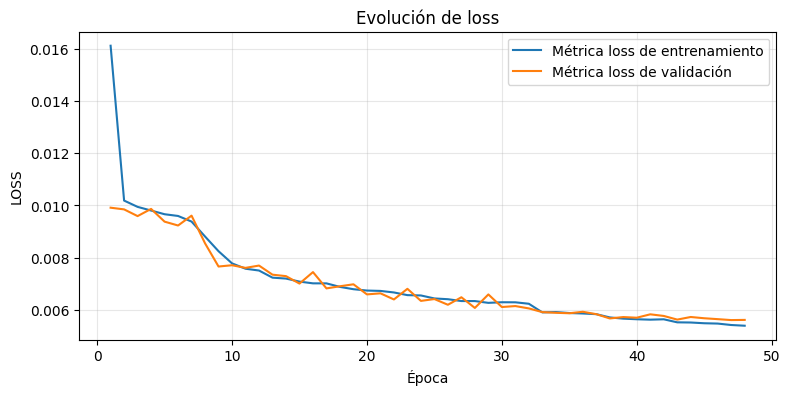

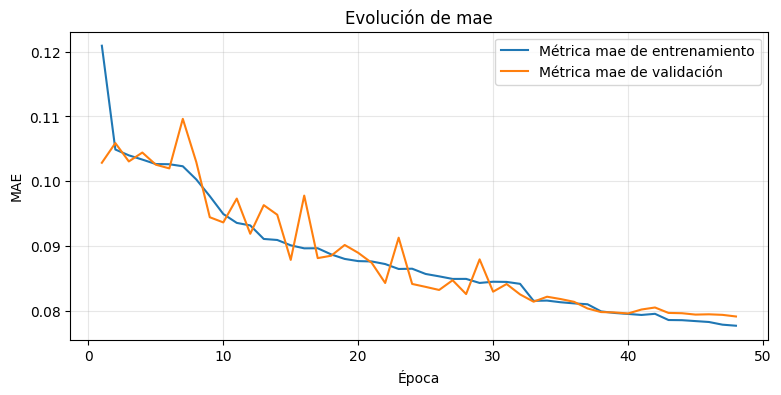

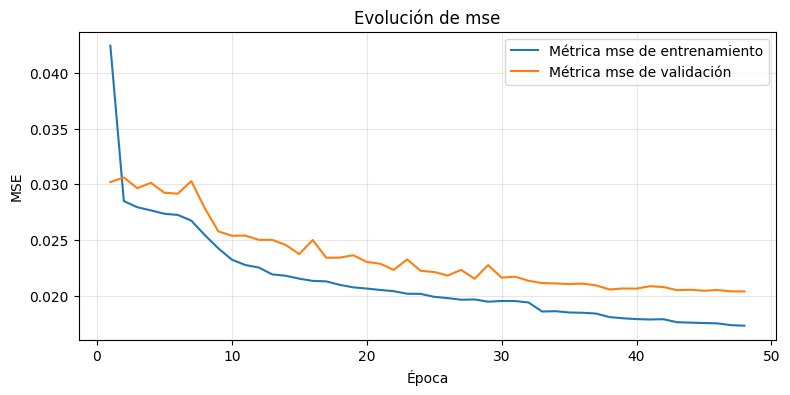

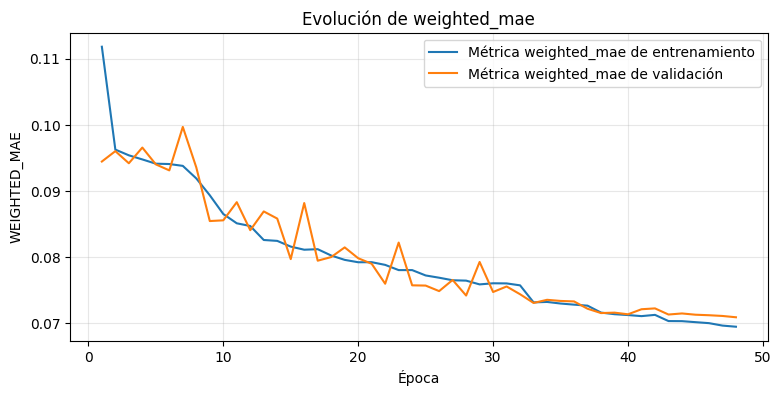

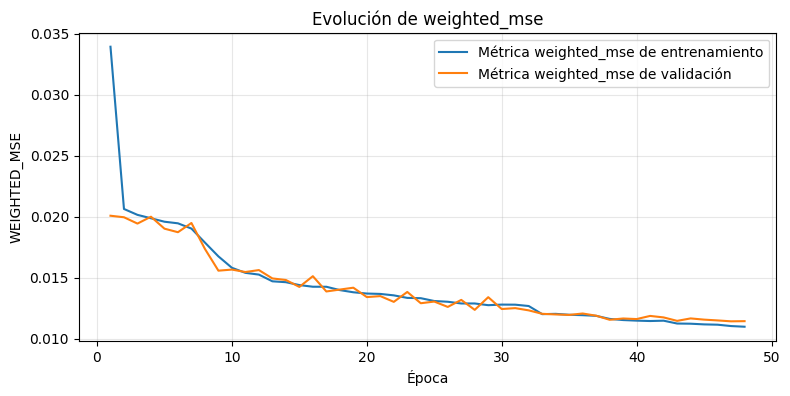

In [10]:
# Importamos funciones a usar para analizar resultados
from model_functions import (
    plot_training_metrics,
    plot_prediction_example,
    plot_worst_best_predictions
)

plot_training_metrics(training_history)

In [11]:
test_metrics = model_cnn_v2.evaluate(
    test_ds,
    verbose=1,
    return_dict=True
)

# Las métricas de test se añaden al resumen del entrenamiento
save_training_summary(
    SUMMARY_PATH,
    training_history,
    test_metrics,
    model_path=MODEL_PATH,
    history_path=HISTORY_PATH,
    batch_size=batch_size
)

print(test_metrics)

64/64 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - loss: 0.0055 - mae: 0.0786 - mse: 0.0165 - weighted_mae: 0.0704 - weighted_mse: 0.0112
{'loss': 0.005522649735212326, 'mae': 0.07856582850217819, 'mse': 0.016474304720759392, 'weighted_mae': 0.07038436084985733, 'weighted_mse': 0.011193614453077316}


In [12]:
y_pred_norm = model_cnn_v2.predict(
    [X_test_flux_interp[..., None], X_test_err_interp[..., None]]
)[..., 0]

# Deshacemos la normalización solo con la escala de la entrada de Gaia
y_pred = y_pred_norm * X_scale_test

128/128 ━━━━━━━━━━━━━━━━━━━━ 63s 484ms/step


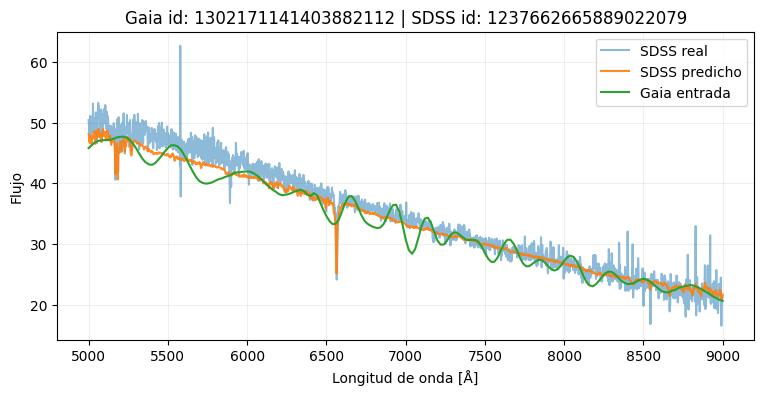

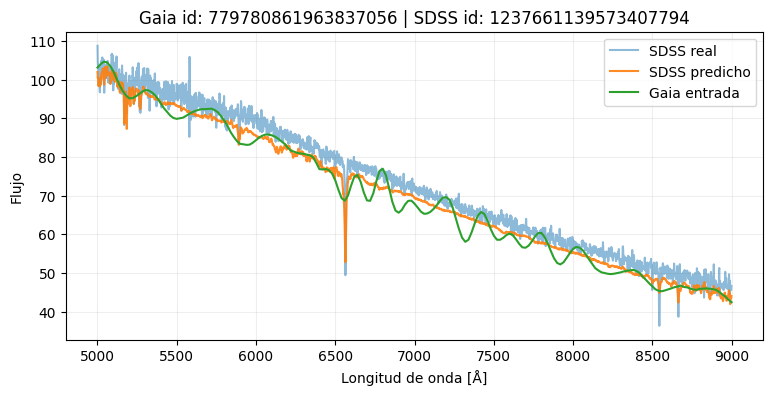

In [13]:
# Mismos objetos usados en las comparativas de la memoria
for i in [123, 191]:
    plot_prediction_example(
        i,
        sdss_wavelength,
        gaia_wavelength,
        y_test,
        y_pred,
        y_id_test,
        X_test,
        X_id_test
    )

MAE:  3.7365
MSE:  47.0663
RMSE: 6.8605


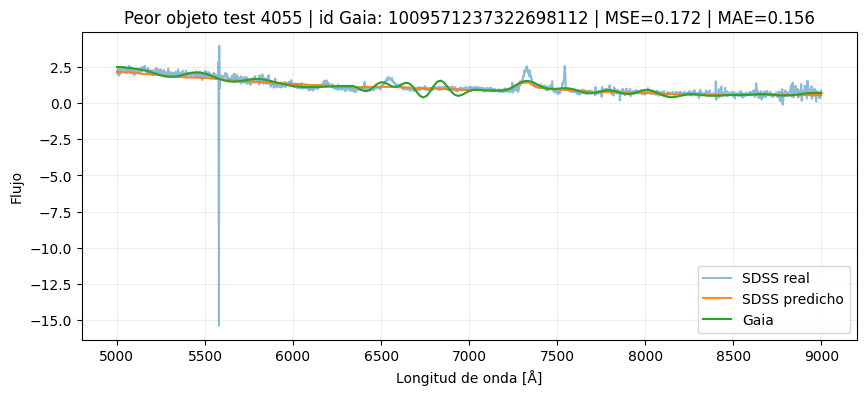

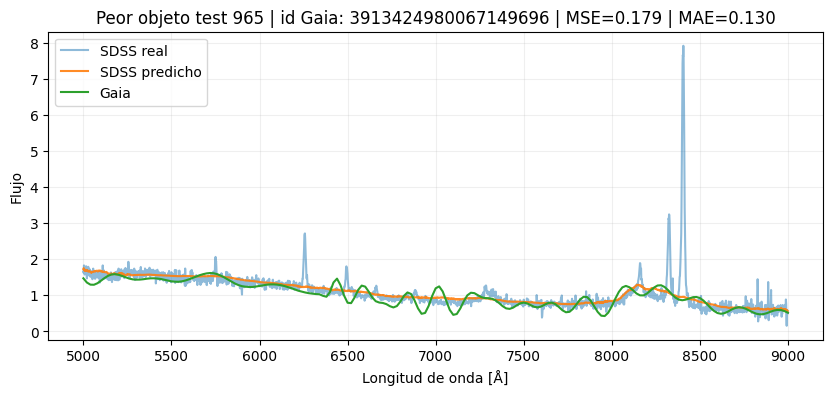

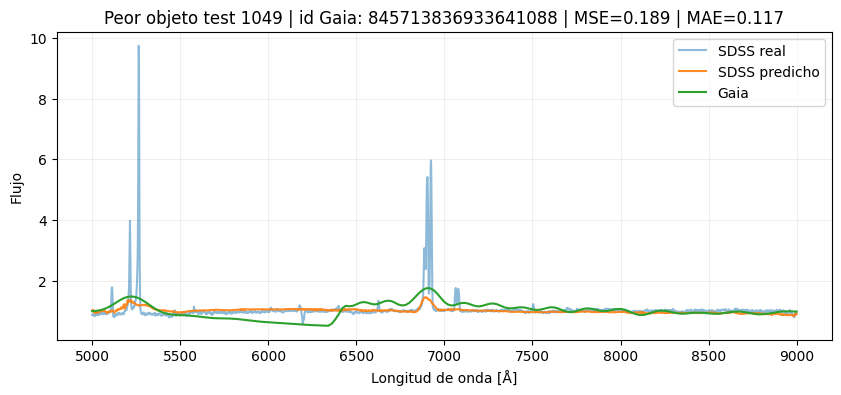

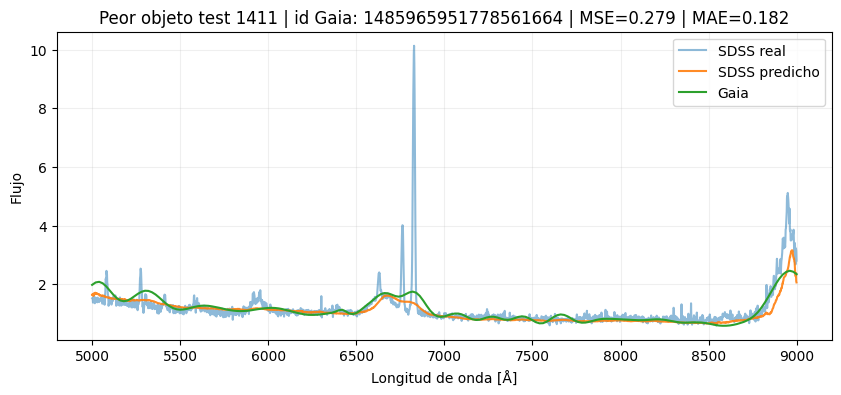

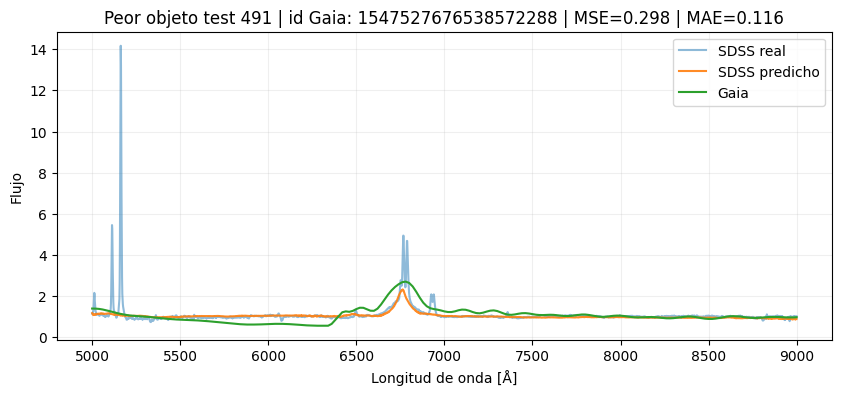

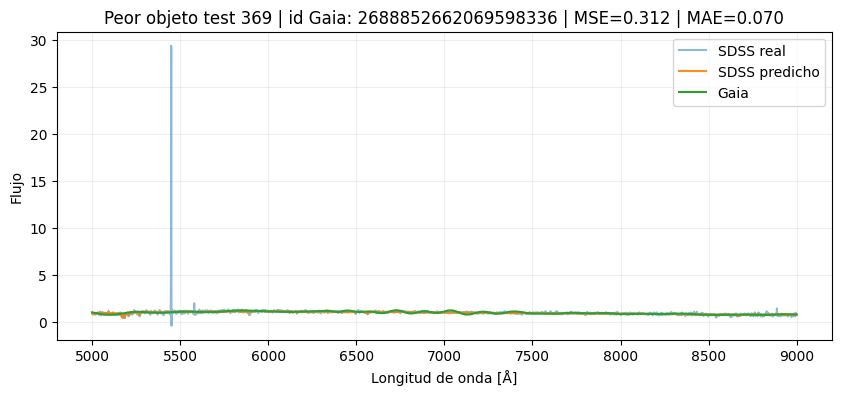

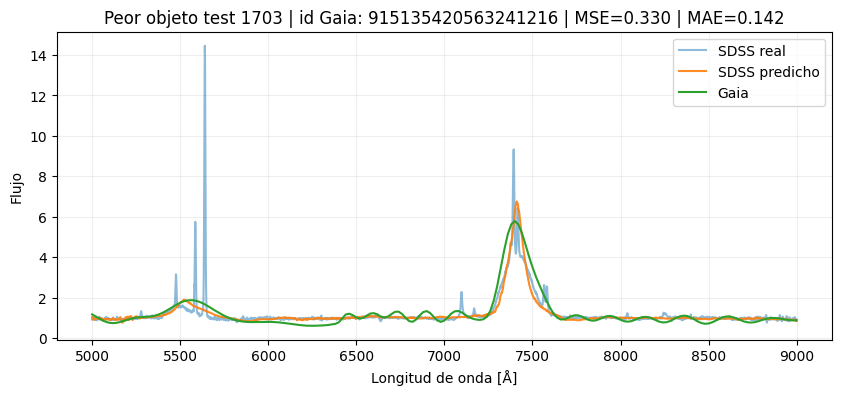

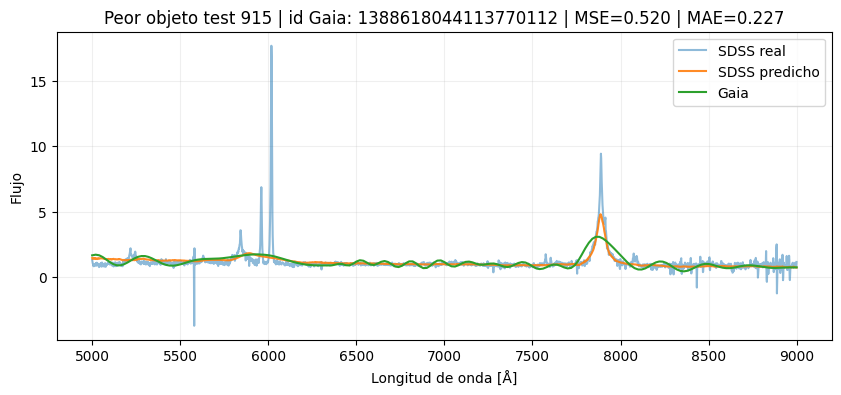

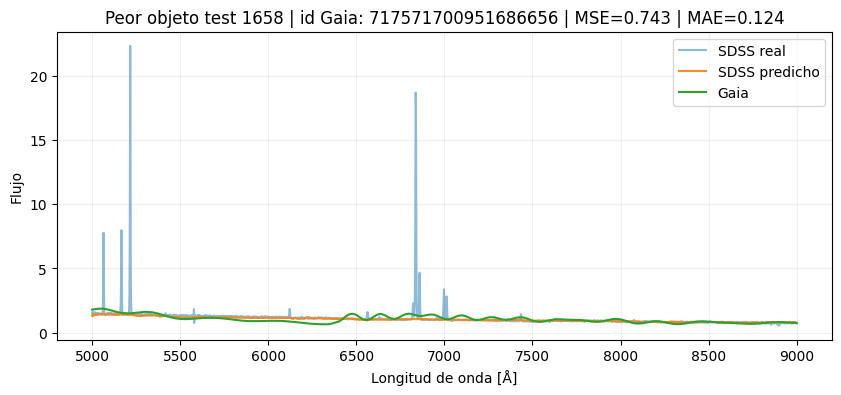

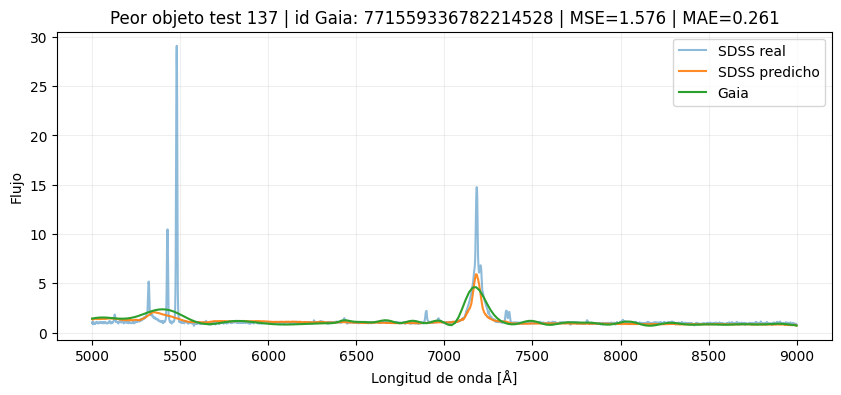

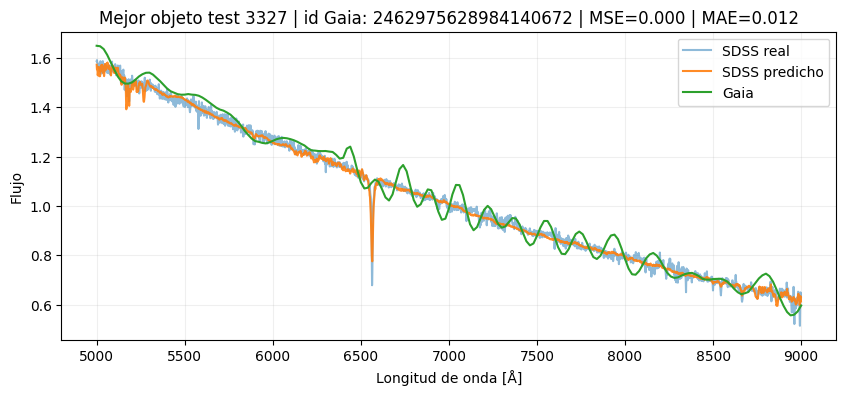

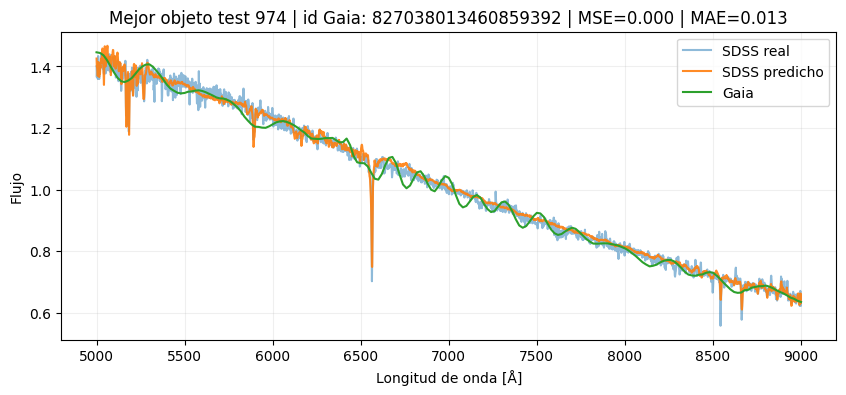

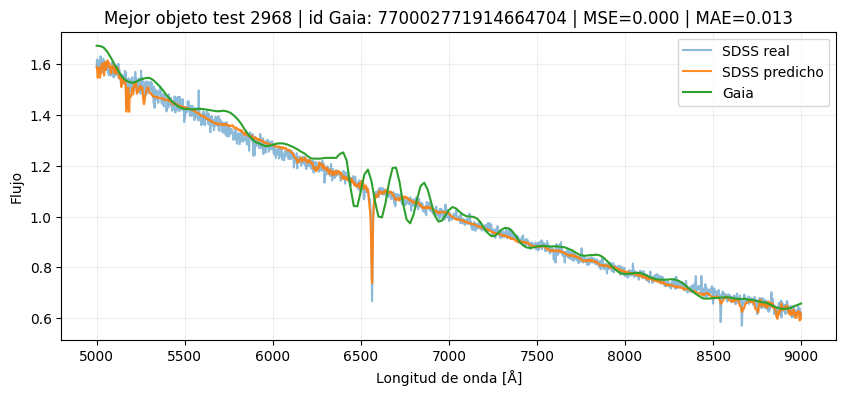

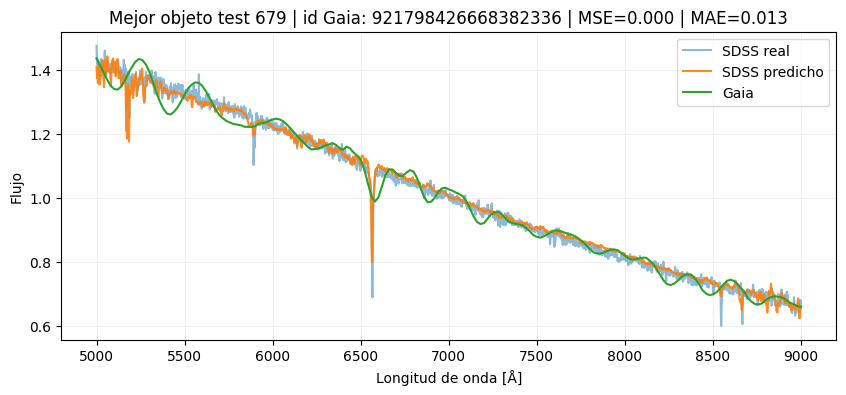

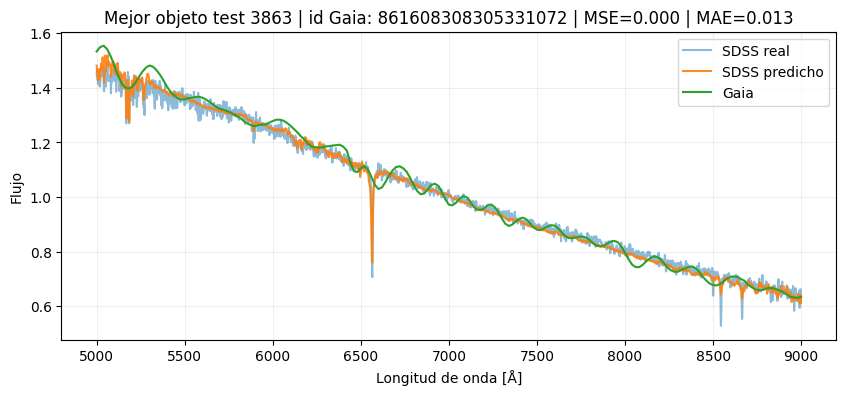

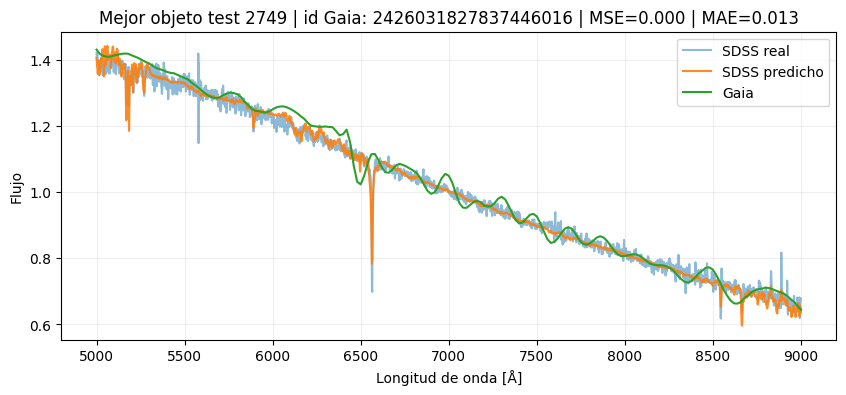

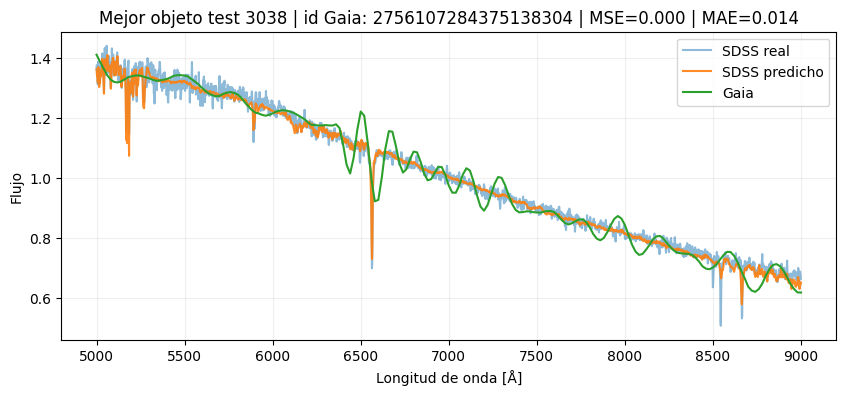

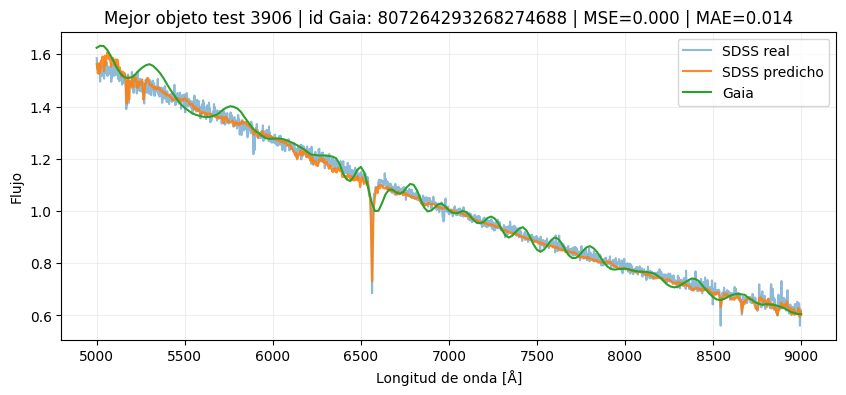

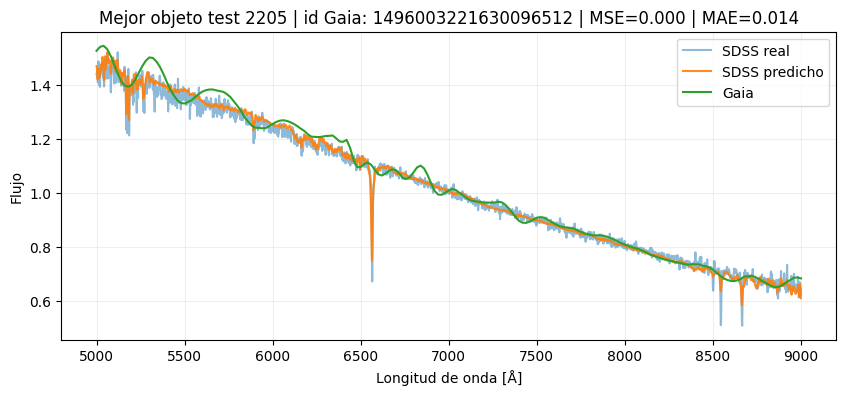

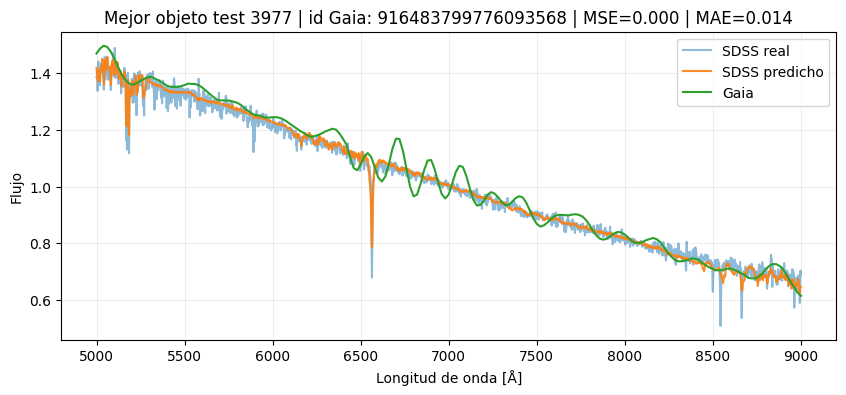

In [14]:
mae = np.mean(np.abs(y_test - y_pred))
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

# Comparación invariante a escala: cada espectro se normaliza con su propia
# mediana, de modo que el ranking refleja el error de forma y no el desajuste
# de calibración absoluta entre Gaia y SDSS
y_test_shape = y_test / np.nanmedian(np.abs(y_test), axis=1, keepdims=True)
y_pred_shape = y_pred / np.nanmedian(np.abs(y_pred), axis=1, keepdims=True)
X_test_shape = X_test / np.nanmedian(np.abs(X_test), axis=1, keepdims=True)

plot_worst_best_predictions(
    y_test_shape,
    y_pred_shape,
    X_test_shape,
    X_id_test,
    sdss_wavelength,
    gaia_wavelength,
    10
)

In [15]:
# El modelo ya está guardado por el checkpoint; lo reescribimos por si esta
# sesión ha continuado el entrenamiento a partir de un checkpoint anterior
model_cnn_v2.save(MODEL_PATH)

Validación física con iSpec: analizamos una muestra de espectros de test comparando los parámetros estelares (Teff, log g, [M/H]) derivados del espectro SDSS real frente a los derivados del espectro predicho por la red.

Esta celda carga el modelo guardado (`cnn-v2.keras`) y genera sus propias predicciones, por lo que no requiere haber entrenado en esta sesión: basta con ejecutar antes las celdas de preparación de datos (carga, normalización, matriz de interpolación y flujos de datos).


128/128 ━━━━━━━━━━━━━━━━━━━━ 73s 558ms/step


/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/lib/iSpec/ispec/atmospheres.py:349: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  delaunay_triangulations, kdtree = pickle.load(open(cache_filename, 'rb'))



Recursos de iSpec cargados correctamente.


Espectros analizados:   0%|          | 0/250 [00:00<?, ?cuerpos estelares/s]

Error analizando espectro real
Error analizando espectro real








Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real


[2026-08-29 11:18:33,846] [WARNING] [atmospheres:_interpolate:110]: Target point '3500.0 2.6911155921887793 -4.559396401646449 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-29 11:18:35,002] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-08-29 11:18:41,790] [WARNING] [atmospheres:_interpolate:110]: Target point '3500.0 2.9241712654505534 -4.433403594361867 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-29 11:18:42,943] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-08-29 11:18:49,692] [WARNING] [atmospheres:_interpolate:110]: Target point '3538.7181018573174 2.120410924434774 -4.114757058198167 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-2
. . . now exiting to system . . .
[2026-08-2

Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real


[2026-08-29 12:19:25,776] [WARNING] [atmospheres:_interpolate:110]: Target point '6886.68566071626 4.396490595769068 -5.5 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-29 12:19:26,932] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.


Error analizando espectro real


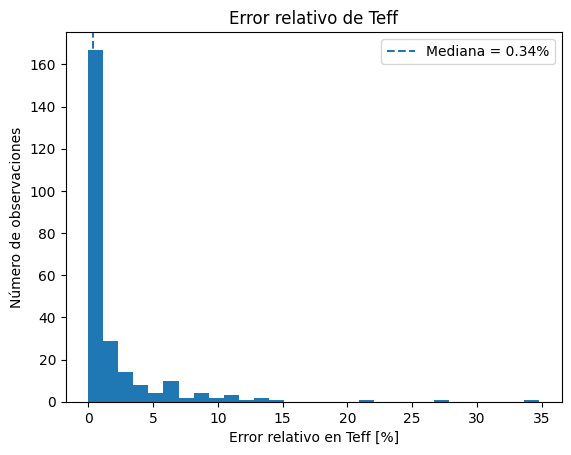

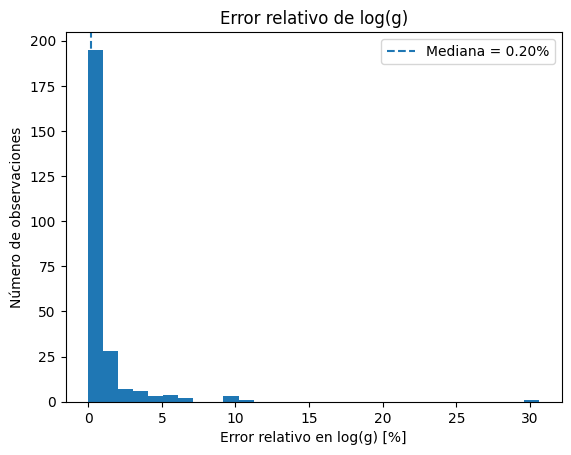

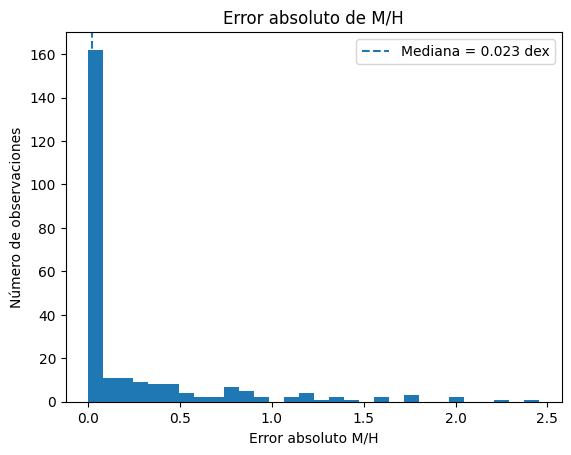

In [16]:
# Recargamos el módulo si ha habido modificaciones
%load_ext autoreload
%autoreload 2

# Funciones de iSpec (el módulo está en 'models', ya añadido a sys.path)
from iSpec_functions import (
    load_ispec_resources,
    analyze_sample_real_vs_pred,
    analyze_ispec_errors
)

import tensorflow as tf
from astropy.table import Table

# Cargamos el modelo entrenado y generamos las predicciones sobre test
model_cnn_v2 = tf.keras.models.load_model(MODEL_PATH)

y_pred_norm = model_cnn_v2.predict(
    [X_test_flux_interp[..., None], X_test_err_interp[..., None]]
)[..., 0]

# Deshacemos la normalización solo con la escala de la entrada de Gaia
y_pred = y_pred_norm * X_scale_test

# Cargamos los recursos de iSpec
resources = load_ispec_resources()

# Cargamos la tabla de Gaia guardada en local
gaia_data_path = DATA_DIR / "gaia_data.ecsv"

gaia_data_table = Table.read(
    gaia_data_path,
    format="ascii.ecsv"
)

# Pasamos a dataframe
gaia_data_df = gaia_data_table.to_pandas()

# Analizamos con iSpec una muestra de espectros reales frente a predichos
results_df_cnn_v2 = analyze_sample_real_vs_pred(
    y_test,
    y_pred,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)

error_df_cnn_v2 = analyze_ispec_errors(results_df_cnn_v2)

